# LLM Call Failure Statistics Analysis

This notebook analyzes the failure statistics from llm_calls.txt files in the LASR runs.

## Log Format
The llm_calls.txt files contain operation logs in the following format:
- Success: `[operation] content`  (e.g., `[mutate] (sin(x) + cos(y))`)
- Failure: `[operation|failed] content`  (e.g., `[mutate|failed] None`)

Where operation can be: `ideas`, `gen_random`, `mutate`, or `crossover`

## Pairing Logic
When two consecutive operations of the same type appear, they are grouped as a pair.
If either operation in the pair fails, the entire pair is marked as failed.

In [134]:
# Configuration - edit exp_labels to control which experiments to include
expr_name = "prompt_think_r1_v4"  # Experiment name prefix for saved files

base_path = "lasr_runs_synthetic_llama32/"
dataset_type = "syn/failure_plot"  # For saving plots

# New parameters for controlling plot order and equation selection

# cmp_scaling_prompt_v3
plot_sequence = []  # Order of experiments to display (by exp_labels keys)
plot_equations = []  # Which equations to plot (by equation number)

# prompt_v4, prompt_think_v4
# plot_sequence = [0,5,1,6,3,8]  # Order of experiments to display (by exp_labels keys)
plot_equations = [2,3,4,5,6,7,8,10]  # Which equations to plot (by equation number)

# prompt_r1_v4
# plot_sequence = [4,12]  # Order of experiments to display (by exp_labels keys)
plot_equations = [6,7]  # Which equations to plot (by equation number)

# Only include the experiments you want by commenting/uncommenting lines
exp_labels = {
    # 'baseline': 'PySR (Baseline)',
    # 0: 'Llama3.2',
    # 1: 'Llama3.2 p',
    # 2: 'Llama3.2 ph',
    # 3: 'Llama3.2',
    4: 'Qwen3-8B',
    5: 'Qwen3-8B-think',
    6: 'DeepSeek V3',
    7: 'DeepSeek R1',
    # 9: 'Llama3.2 p*',
    # 8: 'Qwen3-8B ',
    # 10: 'Qwen3-8B p*',
    # 11: 'Qwen3-8B-think p*',
    # 12: 'Deepseek-V3 p*',
}

base_path = "lasr_syn2/"
dataset_type = "syn2/failure_plot"  # For saving plots

exp_labels = {
    # 0: 'Llama3.2',
    # 1: 'Qwen3-8B',
    # 2: 'Qwen3-8B-think',
    # 3: 'DeepSeek V3',
    4: 'DeepSeek R1',
    # 5: 'Llama3.2 v4',
    # 6: 'Qwen3-8B v4',
    # 7: 'Qwen3-8B-think v4',
    # 8: 'DeepSeek V3 v4',
    # 9: 'N/A',
    # 10: 'Deepseek V3 v4 40 it',
    # 11: 'DeepSeek V3 v4*',
    12: 'DeepSeek R1 v4',
}

In [135]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re



# Function to auto-detect available experiments
def detect_available_experiments(base_path):
    """Auto-detect all available exp_N directories and check if they have data."""
    base_path = Path(base_path)
    available_experiments = []
    
    # Find all exp_N directories
    exp_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.startswith('exp_')]
    
    for exp_dir in sorted(exp_dirs):
        try:
            exp_num = int(exp_dir.name.replace('exp_', ''))
            
            # Check if this experiment has actual data (equation directories)
            eq_dirs = [d for d in exp_dir.iterdir() if d.is_dir() and d.name.isdigit()]
            
            if eq_dirs:
                # Check if at least one equation directory has llm_calls.txt
                has_data = False
                for eq_dir in eq_dirs:
                    if (eq_dir / "llm_calls.txt").exists():
                        has_data = True
                        break
                
                if has_data:
                    available_experiments.append(exp_num)
                    print(f"✓ Found experiment {exp_num} with data ({len(eq_dirs)} equations)")
                else:
                    print(f"! Found experiment {exp_num} but no llm_calls.txt files")
            else:
                print(f"! Found experiment {exp_num} but no equation directories")
                
        except ValueError:
            print(f"! Skipping non-numeric experiment directory: {exp_dir.name}")
    
    return sorted(available_experiments)

print("Experiment Detection:")
print("="*50)

Experiment Detection:


In [136]:
# DEBUG MODE: Set to True to enable detailed debugging output
DEBUG_MODE = False  # Change to True to see detailed operation parsing

# Function to validate parsed data
def validate_parsed_data(counts, file_path):
    """Validate that parsed data is internally consistent"""
    issues = []
    
    # Check that success + failed = total for each operation
    for op in ['ideas', 'gen_random', 'mutate', 'crossover']:
        success = counts.get(f'{op}_success', 0)
        failed = counts.get(f'{op}_failed', 0)
        total = success + failed
        
        # Log any operation with counts
        if total > 0 and DEBUG_MODE:
            print(f"  {op}: {success} success + {failed} failed = {total} total")
    
    # Check for negative values
    for key, value in counts.items():
        if isinstance(value, (int, float)) and value < 0:
            issues.append(f"Negative value for {key}: {value}")
    
    # Report issues
    if issues:
        print(f"⚠️  Validation issues in {file_path}:")
        for issue in issues:
            print(f"    - {issue}")
    
    return len(issues) == 0

In [137]:
def count_patterns_in_file(file_path):
    """Count [ideas], [gen_random], [mutate], [crossover] patterns and their failures in a file.
    
    Based on the actual logging format:
    - Success: [operation] content
    - Failure: [operation|failed] content
    
    Pairing logic:
    - mutate/crossover: Group consecutive operations as pairs (retry mechanism)
    - ideas/gen_random: Usually single operations, but still check for pairs
    
    If any operation in a pair fails, mark the entire pair as failed.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        import re
        
        if DEBUG_MODE:
            print(f"\n🔍 DEBUG: Processing {file_path}")
            print(f"   Total lines: {len(lines)}")
        
        # Find all operation lines with their type and status
        operations = []
        
        for i, line in enumerate(lines):
            line = line.strip()
            
            # Pattern for successful operations: [operation] content
            success_match = re.match(r'^\[(ideas|gen_random|mutate|crossover)\]\s*(.*)$', line)
            if success_match:
                operations.append({
                    'type': success_match.group(1),
                    'failed': False,
                    'content': success_match.group(2),
                    'line_num': i
                })
                if DEBUG_MODE and i < 10:  # Show first 10 matches in debug mode
                    print(f"   Line {i}: [{success_match.group(1)}] (success)")
                continue
            
            # Pattern for failed operations: [operation|failed] content
            failed_match = re.match(r'^\[(ideas|gen_random|mutate|crossover)\|failed\]\s*(.*)$', line)
            if failed_match:
                operations.append({
                    'type': failed_match.group(1),
                    'failed': True,
                    'content': failed_match.group(2),
                    'line_num': i
                })
                if DEBUG_MODE and i < 10:  # Show first 10 matches in debug mode
                    print(f"   Line {i}: [{failed_match.group(1)}|failed]")
        
        if DEBUG_MODE:
            print(f"   Found {len(operations)} operations")
        
        # Group consecutive operations of the same type
        grouped_operations = []
        i = 0
        
        while i < len(operations):
            current = operations[i]
            
            # Check if there's a next operation of the same type that's consecutive
            # For mutate/crossover: more likely to have pairs (retry mechanism)
            # For ideas/gen_random: less likely, but still check
            max_line_gap = 20 if current['type'] in ['mutate', 'crossover'] else 10
            
            if (i + 1 < len(operations) and 
                operations[i + 1]['type'] == current['type'] and
                operations[i + 1]['line_num'] - current['line_num'] < max_line_gap):
                
                # This is a pair of consecutive operations
                next_op = operations[i + 1]
                
                # If either operation failed, the pair failed
                pair_failed = current['failed'] or next_op['failed']
                
                grouped_operations.append({
                    'type': current['type'],
                    'failed': pair_failed,
                    'is_pair': True,
                    'count': 2,  # This represents 2 operations grouped as 1 unit
                    'details': f"Pair: {'FAIL' if current['failed'] else 'OK'} + {'FAIL' if next_op['failed'] else 'OK'} = {'FAIL' if pair_failed else 'OK'}"
                })
                
                if DEBUG_MODE and len(grouped_operations) <= 5:
                    print(f"   Paired {current['type']}: {grouped_operations[-1]['details']}")
                
                i += 2  # Skip both operations as they're now grouped
            else:
                # Single operation (not part of a consecutive pair)
                grouped_operations.append({
                    'type': current['type'],
                    'failed': current['failed'],
                    'is_pair': False,
                    'count': 1,  # Single operation
                    'details': f"Single: {'FAIL' if current['failed'] else 'OK'}"
                })
                
                if DEBUG_MODE and len(grouped_operations) <= 5:
                    print(f"   Single {current['type']}: {grouped_operations[-1]['details']}")
                
                i += 1
        
        # Count the results
        counts = {
            'ideas_success': 0,
            'ideas_failed': 0,
            'gen_random_success': 0,
            'gen_random_failed': 0,
            'mutate_success': 0,
            'mutate_failed': 0,
            'crossover_success': 0,
            'crossover_failed': 0
        }
        
        # Also track detailed statistics
        operation_details = {
            'ideas': {'single': 0, 'pairs': 0, 'total_ops': 0},
            'gen_random': {'single': 0, 'pairs': 0, 'total_ops': 0},
            'mutate': {'single': 0, 'pairs': 0, 'total_ops': 0},
            'crossover': {'single': 0, 'pairs': 0, 'total_ops': 0}
        }
        
        for group in grouped_operations:
            op_type = group['type']
            
            # Count success/failure
            if group['failed']:
                key = f"{op_type}_failed"
            else:
                key = f"{op_type}_success"
            
            if key in counts:
                counts[key] += 1
            
            # Track pairing statistics
            if group['is_pair']:
                operation_details[op_type]['pairs'] += 1
                operation_details[op_type]['total_ops'] += 2
            else:
                operation_details[op_type]['single'] += 1
                operation_details[op_type]['total_ops'] += 1
        
        # Add detailed stats to return (for debugging)
        counts['_debug_details'] = operation_details
        counts['_debug_groups'] = grouped_operations
        
        # Validate the parsed data
        if not validate_parsed_data(counts, file_path):
            print(f"⚠️  Warning: Data validation failed for {file_path}")
        
        return counts
        
    except Exception as e:
        print(f"❌ Error reading {file_path}: {e}")
        import traceback
        if DEBUG_MODE:
            traceback.print_exc()
        
        return {
            'ideas_success': 0,
            'ideas_failed': 0,
            'gen_random_success': 0,
            'gen_random_failed': 0,
            'mutate_success': 0,
            'mutate_failed': 0,
            'crossover_success': 0,
            'crossover_failed': 0,
            '_debug_details': {},
            '_debug_groups': []
        }

In [138]:
def scan_lasr_runs(base_path, exp_labels):
    """Scan the LASR runs directory and collect statistics for experiments defined in exp_labels."""
    base_path = Path(base_path)
    results = []
    
    # Only process experiments defined in exp_labels
    selected_experiments = list(exp_labels.keys())
    
    print(f"\nProcessing {len(selected_experiments)} selected experiments: {selected_experiments}")
    
    # Determine which equations to scan
    if 'plot_equations' in globals() and plot_equations:
        equations_to_scan = plot_equations
        print(f"Scanning only specific equations: {equations_to_scan}")
    else:
        equations_to_scan = range(1, 11)  # Default: scan equations 1-10
        print(f"Scanning all equations (1-10)")
    
    # Scan selected experiments
    for exp_num in selected_experiments:
        exp_dir = base_path / f"exp_{exp_num}"
        if not exp_dir.exists():
            print(f"Warning: exp_{exp_num} directory not found")
            continue
            
        # Scan only the specified equations
        for eq_num in equations_to_scan:
            eq_dir = exp_dir / str(eq_num)
            llm_calls_file = eq_dir / "llm_calls.txt"
            
            if llm_calls_file.exists():
                counts = count_patterns_in_file(llm_calls_file)
                
                # Calculate totals and failure rates for each operation type
                ideas_total = counts['ideas_success'] + counts['ideas_failed']
                gen_random_total = counts['gen_random_success'] + counts['gen_random_failed']
                mutate_total = counts['mutate_success'] + counts['mutate_failed']
                crossover_total = counts['crossover_success'] + counts['crossover_failed']
                
                ideas_failure_rate = counts['ideas_failed'] / ideas_total if ideas_total > 0 else 0
                gen_random_failure_rate = counts['gen_random_failed'] / gen_random_total if gen_random_total > 0 else 0
                mutate_failure_rate = counts['mutate_failed'] / mutate_total if mutate_total > 0 else 0
                crossover_failure_rate = counts['crossover_failed'] / crossover_total if crossover_total > 0 else 0
                
                # Overall statistics
                total_operations = ideas_total + gen_random_total + mutate_total + crossover_total
                total_failures = counts['ideas_failed'] + counts['gen_random_failed'] + counts['mutate_failed'] + counts['crossover_failed']
                overall_failure_rate = total_failures / total_operations if total_operations > 0 else 0
                
                results.append({
                    'experiment': exp_num,
                    'equation': eq_num,
                    # Ideas statistics
                    'ideas_success': counts['ideas_success'],
                    'ideas_failed': counts['ideas_failed'],
                    'ideas_total': ideas_total,
                    'ideas_failure_rate': ideas_failure_rate,
                    # Gen random statistics
                    'gen_random_success': counts['gen_random_success'],
                    'gen_random_failed': counts['gen_random_failed'],
                    'gen_random_total': gen_random_total,
                    'gen_random_failure_rate': gen_random_failure_rate,
                    # Mutate statistics
                    'mutate_success': counts['mutate_success'],
                    'mutate_failed': counts['mutate_failed'],
                    'mutate_total': mutate_total,
                    'mutate_failure_rate': mutate_failure_rate,
                    # Crossover statistics
                    'crossover_success': counts['crossover_success'],
                    'crossover_failed': counts['crossover_failed'],
                    'crossover_total': crossover_total,
                    'crossover_failure_rate': crossover_failure_rate,
                    # Overall statistics
                    'total_operations': total_operations,
                    'total_failures': total_failures,
                    'overall_failure_rate': overall_failure_rate
                })
            else:
                print(f"Missing file: exp_{exp_num}/eq_{eq_num}/llm_calls.txt")
    
    return pd.DataFrame(results)

In [139]:
# Create output directory for this experiment
import os
output_dir = f'/Users/xiaobocheng/final_project/image/{dataset_type}/{expr_name}'
os.makedirs(output_dir, exist_ok=True)
print(f"Created output directory: {output_dir}")

# Scan and collect data using selected experiments from exp_labels
print(f"\nSCANNING SELECTED EXPERIMENTS")
print("="*60)
print(f"Selected experiments: {list(exp_labels.keys())}")
print(f"Labels: {list(exp_labels.values())}")
print("="*60)

# Scan only the experiments defined in exp_labels
df = scan_lasr_runs(base_path, exp_labels)
print(f"\nCollected data for {len(df)} experiment-equation combinations")

if len(df) > 0:
    print("\nExperiment coverage:")
    exp_coverage = df['experiment'].value_counts().sort_index()
    for exp_num, count in exp_coverage.items():
        label = exp_labels.get(exp_num, f"Exp_{exp_num}")
        print(f"  exp_{exp_num} ({label}): {count} equations")
    
    # Check if we have any non-zero counts
    operation_cols = ['ideas_total', 'gen_random_total', 'mutate_total', 'crossover_total']
    print("\nOperation totals across selected experiments:")
    for col in operation_cols:
        if col in df.columns:
            total = df[col].sum()
            print(f"  {col}: {total:,}")
            
    # Calculate overall statistics
    total_ideas_failed = df['ideas_failed'].sum()
    total_gen_random_failed = df['gen_random_failed'].sum()  
    total_mutate_failed = df['mutate_failed'].sum()
    total_crossover_failed = df['crossover_failed'].sum()
    total_all_failed = df['total_failures'].sum()
    
    total_ideas = df['ideas_total'].sum()
    total_gen_random = df['gen_random_total'].sum()
    total_mutate = df['mutate_total'].sum()
    total_crossover = df['crossover_total'].sum()
    total_all_operations = df['total_operations'].sum()
    
    print(f"\nOverall failure statistics:")
    print(f"  Total operations: {total_all_operations:,}")
    print(f"  Total failures: {total_all_failed:,}")
    print(f"  Overall failure rate: {total_all_failed/total_all_operations:.2%}" if total_all_operations > 0 else "  Overall failure rate: N/A")
    
    print(f"\nAll results will be saved in: {output_dir}")
else:
    print("\nNo data collected. Please check file paths and format.")

Created output directory: /Users/xiaobocheng/final_project/image/syn2/failure_plot/prompt_think_r1_v4

SCANNING SELECTED EXPERIMENTS
Selected experiments: [4, 12]
Labels: ['DeepSeek R1', 'DeepSeek R1 v4']

Processing 2 selected experiments: [4, 12]
Scanning only specific equations: [6, 7]

Collected data for 4 experiment-equation combinations

Experiment coverage:
  exp_4 (DeepSeek R1): 2 equations
  exp_12 (DeepSeek R1 v4): 2 equations

Operation totals across selected experiments:
  ideas_total: 40
  gen_random_total: 26
  mutate_total: 723
  crossover_total: 45

Overall failure statistics:
  Total operations: 834
  Total failures: 452
  Overall failure rate: 54.20%

All results will be saved in: /Users/xiaobocheng/final_project/image/syn2/failure_plot/prompt_think_r1_v4


In [140]:
# Summary by experiment (method) for each operation type - needed for plots and CSV export
# IMPORTANT: This data must match exactly with the heatmap data!

# Create summaries for each operation type
method_summary_ideas = df.groupby('experiment').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
method_summary_ideas['ideas_failure_rate'] = method_summary_ideas['ideas_failed'] / method_summary_ideas['ideas_total']
# Add experiment names
method_summary_ideas['experiment_name'] = method_summary_ideas['experiment'].apply(lambda x: exp_labels.get(x, f'Exp_{x}'))

method_summary_gen_random = df.groupby('experiment').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
method_summary_gen_random['gen_random_failure_rate'] = method_summary_gen_random['gen_random_failed'] / method_summary_gen_random['gen_random_total']
# Add experiment names
method_summary_gen_random['experiment_name'] = method_summary_gen_random['experiment'].apply(lambda x: exp_labels.get(x, f'Exp_{x}'))

method_summary_mutate = df.groupby('experiment').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
method_summary_mutate['mutate_failure_rate'] = method_summary_mutate['mutate_failed'] / method_summary_mutate['mutate_total']
# Add experiment names
method_summary_mutate['experiment_name'] = method_summary_mutate['experiment'].apply(lambda x: exp_labels.get(x, f'Exp_{x}'))

method_summary_crossover = df.groupby('experiment').agg({
    'crossover_failed': 'sum',
    'crossover_success': 'sum',
    'crossover_total': 'sum'
}).reset_index()
method_summary_crossover['crossover_failure_rate'] = method_summary_crossover['crossover_failed'] / method_summary_crossover['crossover_total']
# Add experiment names
method_summary_crossover['experiment_name'] = method_summary_crossover['experiment'].apply(lambda x: exp_labels.get(x, f'Exp_{x}'))

method_summary_overall = df.groupby('experiment').agg({
    'total_failures': 'sum',
    'total_operations': 'sum'
}).reset_index()
method_summary_overall['overall_failure_rate'] = method_summary_overall['total_failures'] / method_summary_overall['total_operations']
# Add experiment names
method_summary_overall['experiment_name'] = method_summary_overall['experiment'].apply(lambda x: exp_labels.get(x, f'Exp_{x}'))

# Data Integrity Check: Verify that the aggregated data matches
print("=== DATA INTEGRITY CHECK ===")
print(f"Total rows in dataframe: {len(df)}")
print(f"Experiments covered: {sorted(df['experiment'].unique())}")
print(f"Equations covered: {sorted(df['equation'].unique())}")

# Verify that individual operation totals sum to overall totals
for exp_num in sorted(df['experiment'].unique()):
    exp_data = df[df['experiment'] == exp_num]
    sum_operations = (exp_data['ideas_total'].sum() + exp_data['gen_random_total'].sum() + 
                     exp_data['mutate_total'].sum() + exp_data['crossover_total'].sum())
    overall_operations = exp_data['total_operations'].sum()
    if sum_operations != overall_operations:
        print(f"⚠️  WARNING: Exp {exp_num} operation sum mismatch: {sum_operations} vs {overall_operations}")
    else:
        print(f"✓ Exp {exp_num} operation totals verified: {overall_operations}")

# Add metadata to CSV files for tracking
import datetime
metadata = {
    'generated_at': datetime.datetime.now().isoformat(),
    'experiment_name': expr_name,
    'base_path': base_path,
    'dataset_type': dataset_type,
    'experiments_included': [int(x) for x in exp_labels.keys()],  # Convert to regular Python int
    'equations_scanned': [int(x) for x in sorted(df['equation'].unique())] if len(df) > 0 else []  # Convert numpy int64 to Python int
}

# Save metadata
import json
with open(f'{output_dir}/{expr_name}_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Save all method summaries to CSV files with enhanced headers
def save_csv_with_metadata(df, filepath, description):
    """Save DataFrame to CSV with metadata header"""
    with open(filepath, 'w') as f:
        f.write(f"# {description}\n")
        f.write(f"# Generated: {metadata['generated_at']}\n")
        f.write(f"# Experiments: {metadata['experiments_included']}\n")
        f.write(f"# Equations: {metadata['equations_scanned']}\n")
        df.to_csv(f, index=False)

# Reorder columns to put experiment_name first for better readability
def reorder_columns_with_name(df):
    """Reorder columns to have experiment_name right after experiment"""
    cols = df.columns.tolist()
    if 'experiment_name' in cols:
        cols.remove('experiment_name')
        cols.insert(1, 'experiment_name')
    return df[cols]

# DISABLED: Individual CSV saves - all data is in the comprehensive summary
# save_csv_with_metadata(reorder_columns_with_name(method_summary_ideas), 
#                       f'{output_dir}/{expr_name}_method_summary_ideas.csv',
#                       "Ideas operation failure statistics by experiment")
# save_csv_with_metadata(reorder_columns_with_name(method_summary_gen_random), 
#                       f'{output_dir}/{expr_name}_method_summary_gen_random.csv',
#                       "Gen Random operation failure statistics by experiment")
# save_csv_with_metadata(reorder_columns_with_name(method_summary_mutate), 
#                       f'{output_dir}/{expr_name}_method_summary_mutate.csv',
#                       "Mutate operation failure statistics by experiment")
# save_csv_with_metadata(reorder_columns_with_name(method_summary_crossover), 
#                       f'{output_dir}/{expr_name}_method_summary_crossover.csv',
#                       "Crossover operation failure statistics by experiment")
# save_csv_with_metadata(reorder_columns_with_name(method_summary_overall), 
#                       f'{output_dir}/{expr_name}_method_summary_overall.csv',
#                       "Overall failure statistics by experiment")

# Add experiment names to detailed dataframe
df_with_names = df.copy()
df_with_names['experiment_name'] = df_with_names['experiment'].apply(lambda x: exp_labels.get(x, f'Exp_{x}'))
# Reorder columns to have experiment_name after experiment
cols = df_with_names.columns.tolist()
cols.remove('experiment_name')
cols.insert(1, 'experiment_name')
df_with_names = df_with_names[cols]

# Save the raw detailed dataframe for full transparency
save_csv_with_metadata(df_with_names, 
                      f'{output_dir}/{expr_name}_detailed_data.csv',
                      "Detailed failure statistics by experiment and equation")

# Save method summaries to text file with enhanced formatting
method_summary_path = f'{output_dir}/{expr_name}_method_summaries.txt'
with open(method_summary_path, 'w') as f:
    f.write(f"LLM Call Failure Statistics Summary\n")
    f.write(f"{'='*60}\n")
    f.write(f"Generated: {metadata['generated_at']}\n")
    f.write(f"Experiment Name: {expr_name}\n")
    f.write(f"Base Path: {base_path}\n")
    f.write(f"Experiments Analyzed: {metadata['experiments_included']}\n")
    f.write(f"Equations Scanned: {metadata['equations_scanned']}\n")
    f.write(f"{'='*60}\n\n")
    
    f.write("Summary by Method (Experiment) - Ideas:\n")
    f.write(reorder_columns_with_name(method_summary_ideas).to_string(index=False) + "\n\n")
    
    f.write("Summary by Method (Experiment) - Gen Random:\n")
    f.write(reorder_columns_with_name(method_summary_gen_random).to_string(index=False) + "\n\n")
    
    f.write("Summary by Method (Experiment) - Mutate:\n")
    f.write(reorder_columns_with_name(method_summary_mutate).to_string(index=False) + "\n\n")
    
    f.write("Summary by Method (Experiment) - Crossover:\n")
    f.write(reorder_columns_with_name(method_summary_crossover).to_string(index=False) + "\n\n")
    
    f.write("Summary by Method (Experiment) - Overall:\n")
    f.write(reorder_columns_with_name(method_summary_overall).to_string(index=False) + "\n")

print("\n=== CSV EXPORT COMPLETED ===")
# print(f"✓ Exported {expr_name}_method_summary_ideas.csv")
# print(f"✓ Exported {expr_name}_method_summary_gen_random.csv")
# print(f"✓ Exported {expr_name}_method_summary_mutate.csv")
# print(f"✓ Exported {expr_name}_method_summary_crossover.csv")
# print(f"✓ Exported {expr_name}_method_summary_overall.csv")
print(f"✓ Exported {expr_name}_detailed_data.csv (raw data)")
print(f"✓ Exported {expr_name}_metadata.json")
print(f"✓ Exported {expr_name}_method_summaries.txt")
print("ℹ️  Individual operation CSV files disabled - use comprehensive summary instead")

# Display summaries with names
print("\nSummary by Method (Experiment) - Ideas:")
print(reorder_columns_with_name(method_summary_ideas))
print("\nSummary by Method (Experiment) - Gen Random:")
print(reorder_columns_with_name(method_summary_gen_random))
print("\nSummary by Method (Experiment) - Mutate:")
print(reorder_columns_with_name(method_summary_mutate))
print("\nSummary by Method (Experiment) - Crossover:")
print(reorder_columns_with_name(method_summary_crossover))
print("\nSummary by Method (Experiment) - Overall:")
print(reorder_columns_with_name(method_summary_overall))

=== DATA INTEGRITY CHECK ===
Total rows in dataframe: 4
Experiments covered: [4, 12]
Equations covered: [6, 7]
✓ Exp 4 operation totals verified: 91
✓ Exp 12 operation totals verified: 743

=== CSV EXPORT COMPLETED ===
✓ Exported prompt_think_r1_v4_detailed_data.csv (raw data)
✓ Exported prompt_think_r1_v4_metadata.json
✓ Exported prompt_think_r1_v4_method_summaries.txt
ℹ️  Individual operation CSV files disabled - use comprehensive summary instead

Summary by Method (Experiment) - Ideas:
   experiment experiment_name  ideas_failed  ideas_success  ideas_total  \
0           4     DeepSeek R1             0             20           20   
1          12  DeepSeek R1 v4             0             20           20   

   ideas_failure_rate  
0                 0.0  
1                 0.0  

Summary by Method (Experiment) - Gen Random:
   experiment experiment_name  gen_random_failed  gen_random_success  \
0           4     DeepSeek R1                  1                   3   
1          12  Dee

In [141]:
# Summary by experiment (method) for each operation type - needed for plots
method_summary_ideas = df.groupby('experiment').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
method_summary_ideas['ideas_failure_rate'] = method_summary_ideas['ideas_failed'] / method_summary_ideas['ideas_total']

method_summary_gen_random = df.groupby('experiment').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
method_summary_gen_random['gen_random_failure_rate'] = method_summary_gen_random['gen_random_failed'] / method_summary_gen_random['gen_random_total']

method_summary_mutate = df.groupby('experiment').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
method_summary_mutate['mutate_failure_rate'] = method_summary_mutate['mutate_failed'] / method_summary_mutate['mutate_total']

method_summary_crossover = df.groupby('experiment').agg({
    'crossover_failed': 'sum',
    'crossover_success': 'sum',
    'crossover_total': 'sum'
}).reset_index()
method_summary_crossover['crossover_failure_rate'] = method_summary_crossover['crossover_failed'] / method_summary_crossover['crossover_total']

method_summary_overall = df.groupby('experiment').agg({
    'total_failures': 'sum',
    'total_operations': 'sum'
}).reset_index()
method_summary_overall['overall_failure_rate'] = method_summary_overall['total_failures'] / method_summary_overall['total_operations']

# Print summaries for reference
print("Summary by Method (Experiment) - Overall:")
print(method_summary_overall)

Summary by Method (Experiment) - Overall:
   experiment  total_failures  total_operations  overall_failure_rate
0           4              44                91              0.483516
1          12             408               743              0.549125


In [142]:
# Summary by equation for each operation type - needed for plots and CSV export
equation_summary_ideas = df.groupby('equation').agg({
    'ideas_failed': 'sum',
    'ideas_success': 'sum',
    'ideas_total': 'sum'
}).reset_index()
equation_summary_ideas['ideas_failure_rate'] = equation_summary_ideas['ideas_failed'] / equation_summary_ideas['ideas_total']

equation_summary_gen_random = df.groupby('equation').agg({
    'gen_random_failed': 'sum',
    'gen_random_success': 'sum',
    'gen_random_total': 'sum'
}).reset_index()
equation_summary_gen_random['gen_random_failure_rate'] = equation_summary_gen_random['gen_random_failed'] / equation_summary_gen_random['gen_random_total']

equation_summary_mutate = df.groupby('equation').agg({
    'mutate_failed': 'sum',
    'mutate_success': 'sum',
    'mutate_total': 'sum'
}).reset_index()
equation_summary_mutate['mutate_failure_rate'] = equation_summary_mutate['mutate_failed'] / equation_summary_mutate['mutate_total']

equation_summary_crossover = df.groupby('equation').agg({
    'crossover_failed': 'sum',
    'crossover_success': 'sum',
    'crossover_total': 'sum'
}).reset_index()
equation_summary_crossover['crossover_failure_rate'] = equation_summary_crossover['crossover_failed'] / equation_summary_crossover['crossover_total']

equation_summary_overall = df.groupby('equation').agg({
    'total_failures': 'sum',
    'total_operations': 'sum'
}).reset_index()
equation_summary_overall['overall_failure_rate'] = equation_summary_overall['total_failures'] / equation_summary_overall['total_operations']

# DISABLED: Individual equation CSV saves - all data is in the comprehensive summary
# save_csv_with_metadata(equation_summary_ideas, 
#                       f'{output_dir}/{expr_name}_equation_summary_ideas.csv',
#                       "Ideas operation failure statistics by equation")
# save_csv_with_metadata(equation_summary_gen_random, 
#                       f'{output_dir}/{expr_name}_equation_summary_gen_random.csv',
#                       "Gen Random operation failure statistics by equation")
# save_csv_with_metadata(equation_summary_mutate, 
#                       f'{output_dir}/{expr_name}_equation_summary_mutate.csv',
#                       "Mutate operation failure statistics by equation")
# save_csv_with_metadata(equation_summary_crossover, 
#                       f'{output_dir}/{expr_name}_equation_summary_crossover.csv',
#                       "Crossover operation failure statistics by equation")
# save_csv_with_metadata(equation_summary_overall, 
#                       f'{output_dir}/{expr_name}_equation_summary_overall.csv',
#                       "Overall failure statistics by equation")

# Save equation summaries to text file
equation_summary_path = f'{output_dir}/{expr_name}_equation_summaries.txt'
with open(equation_summary_path, 'w') as f:
    f.write(f"LLM Call Failure Statistics Summary by Equation\n")
    f.write(f"{'='*60}\n")
    f.write(f"Generated: {metadata['generated_at']}\n")
    f.write(f"Experiment Name: {expr_name}\n")
    f.write(f"{'='*60}\n\n")
    
    f.write("Summary by Equation - Ideas:\n")
    f.write(equation_summary_ideas.to_string(index=False) + "\n\n")
    
    f.write("Summary by Equation - Gen Random:\n")
    f.write(equation_summary_gen_random.to_string(index=False) + "\n\n")
    
    f.write("Summary by Equation - Mutate:\n")
    f.write(equation_summary_mutate.to_string(index=False) + "\n\n")
    
    f.write("Summary by Equation - Crossover:\n")
    f.write(equation_summary_crossover.to_string(index=False) + "\n\n")
    
    f.write("Summary by Equation - Overall:\n")
    f.write(equation_summary_overall.to_string(index=False) + "\n")

print("\n=== EQUATION-LEVEL CSV EXPORT COMPLETED ===")
# print(f"✓ Exported {expr_name}_equation_summary_*.csv files")
print(f"✓ Exported {expr_name}_equation_summaries.txt")
print("ℹ️  Individual equation CSV files disabled - use comprehensive summary instead")

# Print summaries for reference
print("\nSummary by Equation - Overall:")
print(equation_summary_overall)


=== EQUATION-LEVEL CSV EXPORT COMPLETED ===
✓ Exported prompt_think_r1_v4_equation_summaries.txt
ℹ️  Individual equation CSV files disabled - use comprehensive summary instead

Summary by Equation - Overall:
   equation  total_failures  total_operations  overall_failure_rate
0         6             191               425              0.449412
1         7             261               409              0.638142


Saved Plot 1 to /Users/xiaobocheng/final_project/image/syn2/failure_plot/prompt_think_r1_v4/prompt_think_r1_v4_failure_heatmaps.png


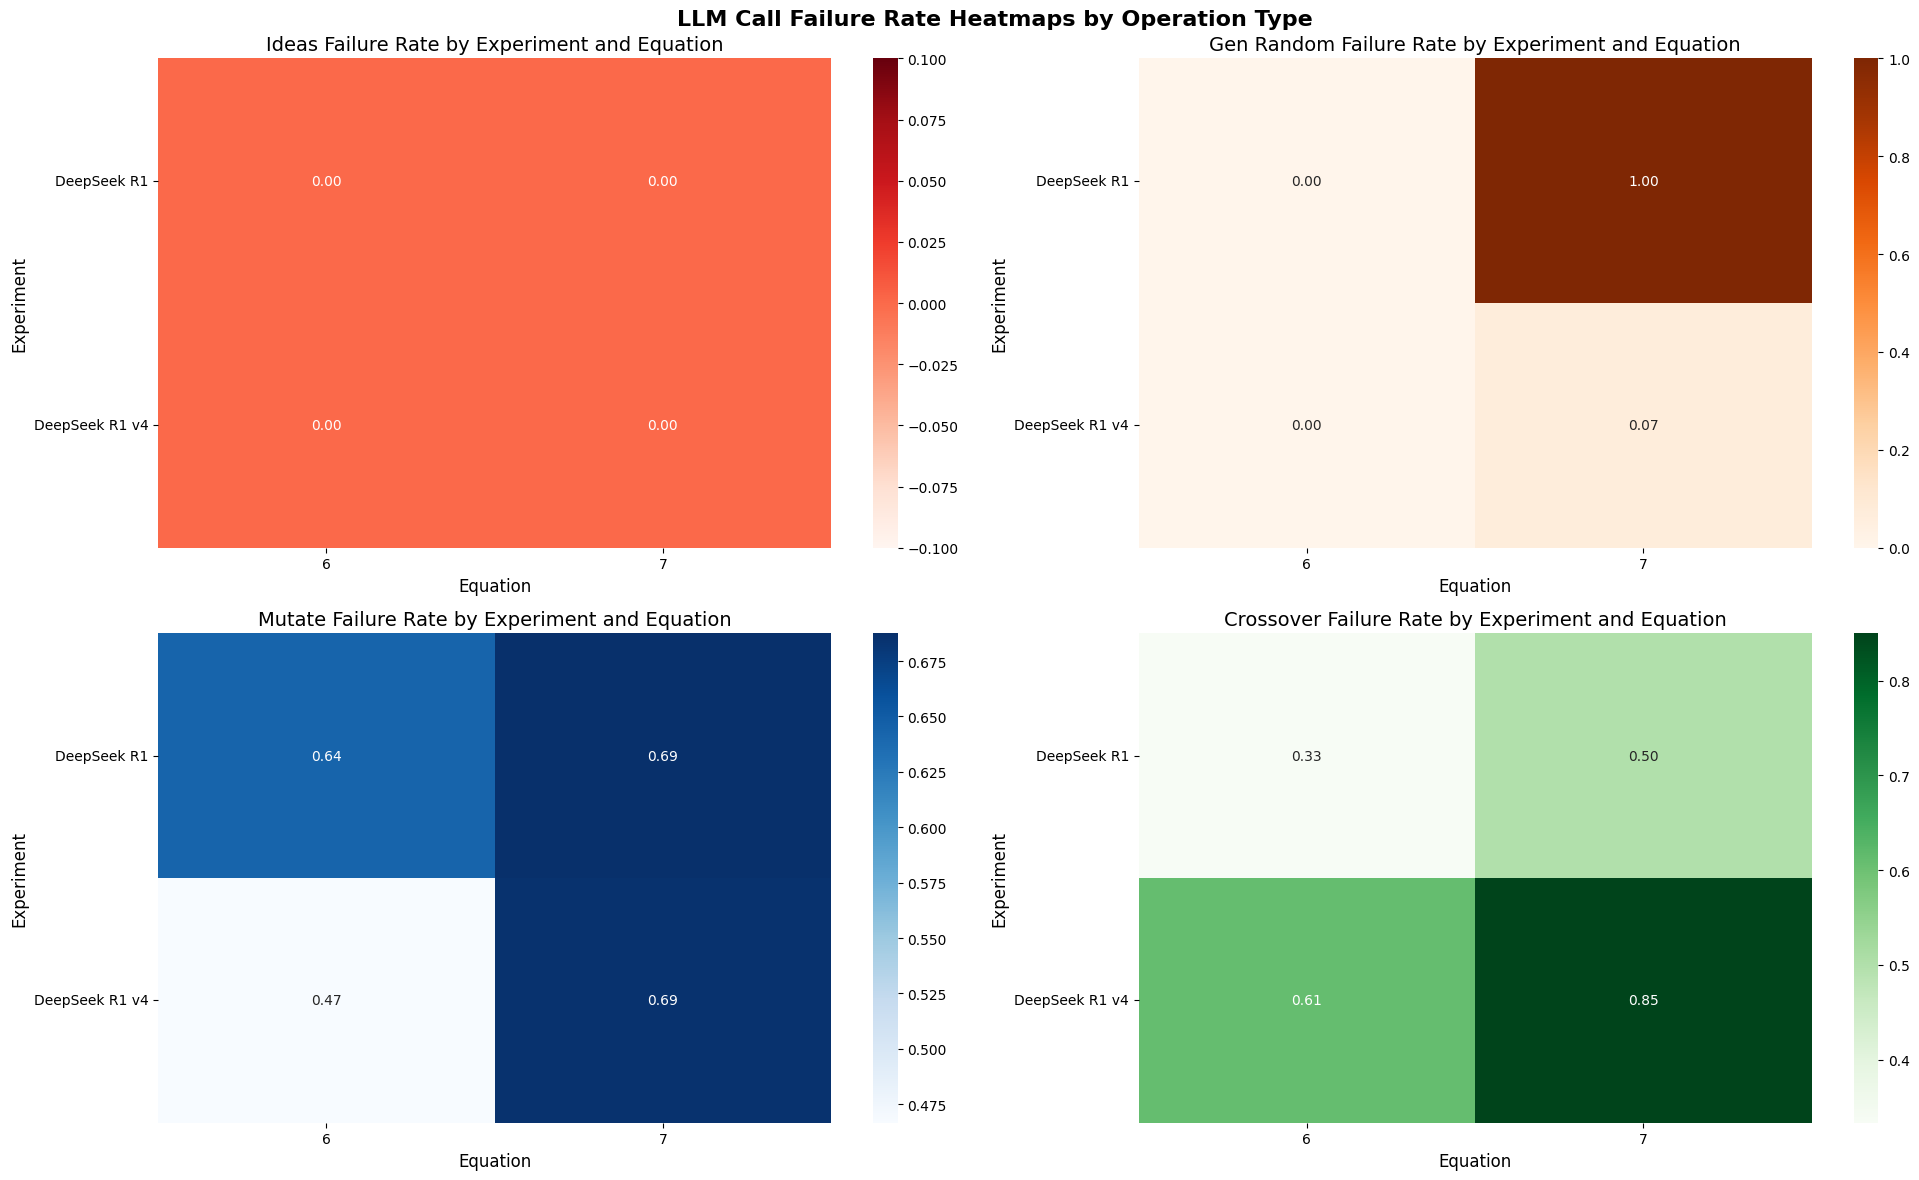

Saved Plot 2 to /Users/xiaobocheng/final_project/image/syn2/failure_plot/prompt_think_r1_v4/prompt_think_r1_v4_failure_by_method.png


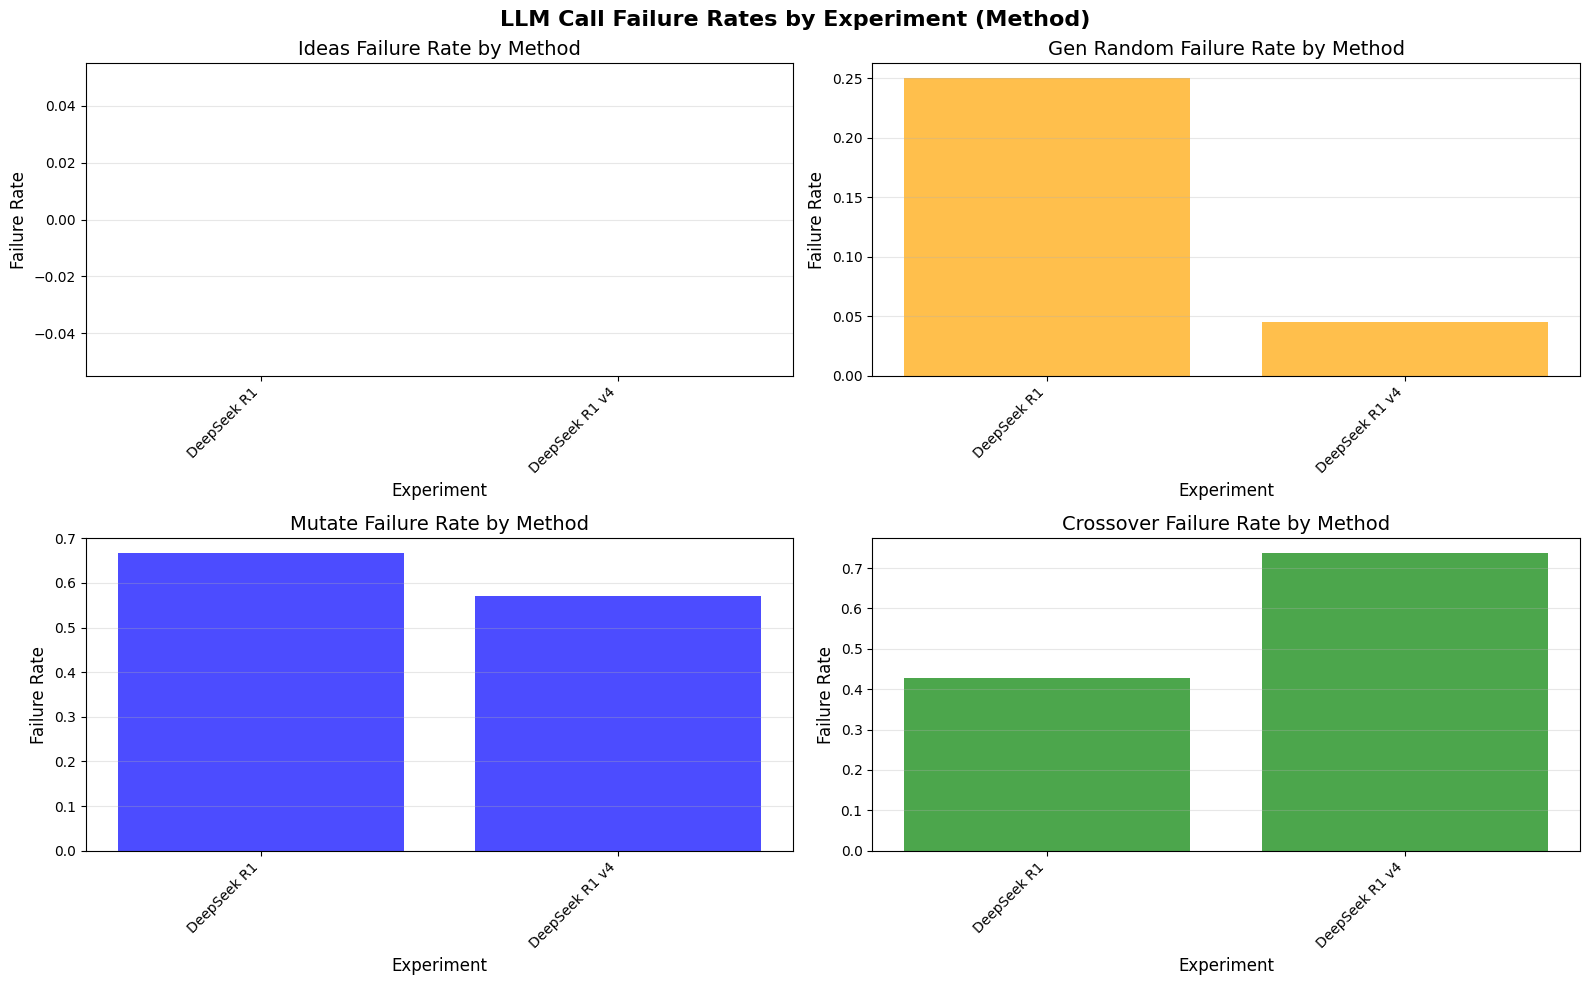

Saved Plot 3 to /Users/xiaobocheng/final_project/image/syn2/failure_plot/prompt_think_r1_v4/prompt_think_r1_v4_failure_by_equation.png


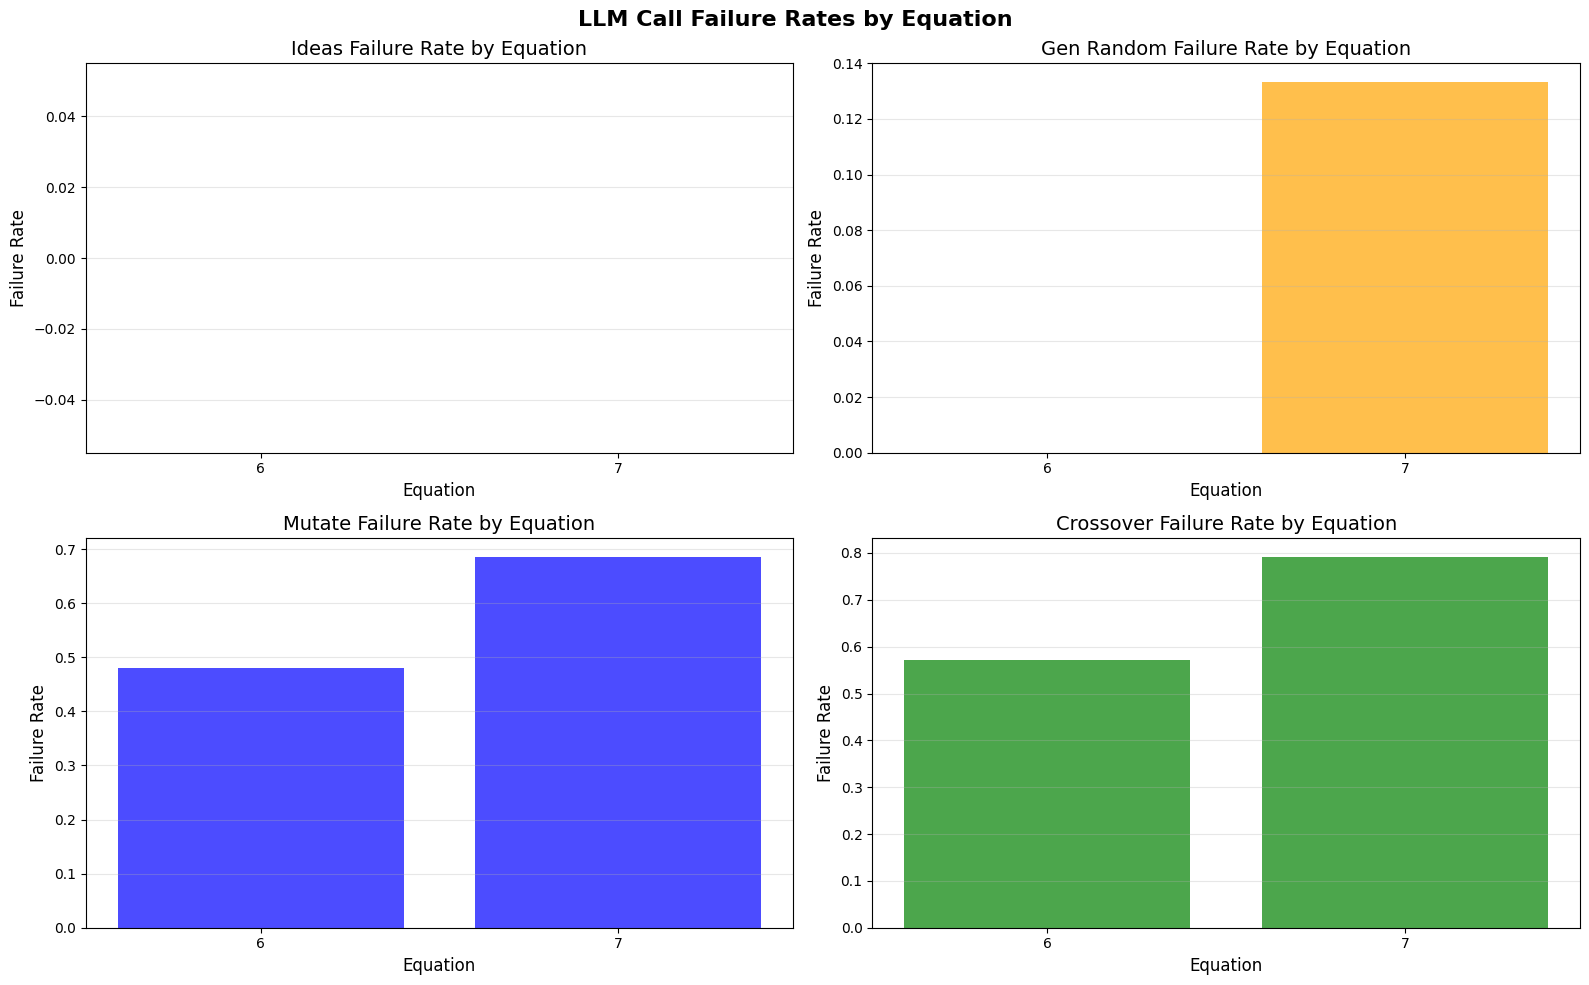


Visualization Summary:
- Processing 2 experiments: [4, 12]
- Experiment labels: ['DeepSeek R1', 'DeepSeek R1 v4']
- Plotting only equations: [6, 7]
- Table dimensions: 2x2 (experiments x equations)
- All files saved in: /Users/xiaobocheng/final_project/image/syn2/failure_plot/prompt_think_r1_v4


In [143]:
# PLOT 1: Heatmaps for each operation type
selected_experiments = sorted(df['experiment'].unique())
num_experiments = len(selected_experiments)

# Apply plot_sequence if specified
if 'plot_sequence' in globals() and plot_sequence:
    # Filter selected_experiments to only include those in plot_sequence and maintain the specified order
    ordered_experiments = []
    for exp_key in plot_sequence:
        if exp_key in selected_experiments:
            ordered_experiments.append(exp_key)
    # Add any remaining experiments not in plot_sequence at the end
    for exp_key in selected_experiments:
        if exp_key not in ordered_experiments:
            ordered_experiments.append(exp_key)
    selected_experiments = ordered_experiments

# Create pivot tables for heatmaps - reindex to match the desired order
ideas_failure_rate_table = df.pivot(index='experiment', columns='equation', values='ideas_failure_rate').reindex(selected_experiments)
gen_random_failure_rate_table = df.pivot(index='experiment', columns='equation', values='gen_random_failure_rate').reindex(selected_experiments)
mutate_failure_rate_table = df.pivot(index='experiment', columns='equation', values='mutate_failure_rate').reindex(selected_experiments)
crossover_failure_rate_table = df.pivot(index='experiment', columns='equation', values='crossover_failure_rate').reindex(selected_experiments)
overall_failure_rate_table = df.pivot(index='experiment', columns='equation', values='overall_failure_rate').reindex(selected_experiments)

# Calculate appropriate figure size based on number of experiments
fig_height = max(12, num_experiments * 1.5)  # Scale with experiments
fig, axes = plt.subplots(2, 2, figsize=(20, fig_height))

# Create experiment labels for current experiments
current_exp_labels = [exp_labels.get(i, f'Exp_{i}') for i in selected_experiments]

# Ideas heatmap
sns.heatmap(ideas_failure_rate_table, annot=True, fmt='.2f', cmap='Reds', ax=axes[0,0])
axes[0,0].set_title('Ideas Failure Rate by Experiment and Equation', fontsize=14)
axes[0,0].set_xlabel('Equation', fontsize=12)
axes[0,0].set_ylabel('Experiment', fontsize=12)
axes[0,0].set_yticklabels(current_exp_labels, rotation=0)

# Gen Random heatmap
sns.heatmap(gen_random_failure_rate_table, annot=True, fmt='.2f', cmap='Oranges', ax=axes[0,1])
axes[0,1].set_title('Gen Random Failure Rate by Experiment and Equation', fontsize=14)
axes[0,1].set_xlabel('Equation', fontsize=12)
axes[0,1].set_ylabel('Experiment', fontsize=12)
axes[0,1].set_yticklabels(current_exp_labels, rotation=0)

# Mutate heatmap
sns.heatmap(mutate_failure_rate_table, annot=True, fmt='.2f', cmap='Blues', ax=axes[1,0])
axes[1,0].set_title('Mutate Failure Rate by Experiment and Equation', fontsize=14)
axes[1,0].set_xlabel('Equation', fontsize=12)
axes[1,0].set_ylabel('Experiment', fontsize=12)
axes[1,0].set_yticklabels(current_exp_labels, rotation=0)

# Crossover heatmap
sns.heatmap(crossover_failure_rate_table, annot=True, fmt='.2f', cmap='Greens', ax=axes[1,1])
axes[1,1].set_title('Crossover Failure Rate by Experiment and Equation', fontsize=14)
axes[1,1].set_xlabel('Equation', fontsize=12)
axes[1,1].set_ylabel('Experiment', fontsize=12)
axes[1,1].set_yticklabels(current_exp_labels, rotation=0)

plt.suptitle('LLM Call Failure Rate Heatmaps by Operation Type', fontsize=16, fontweight='bold')
plt.tight_layout()

# Save the plot in the experiment folder with expr_name prefix
save_path = f'{output_dir}/{expr_name}_failure_heatmaps.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved Plot 1 to {save_path}")

plt.show()

# PLOT 2: Bar plots by method for each operation type
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Reorder method summaries to match plot_sequence
method_summary_ideas_ordered = method_summary_ideas.set_index('experiment').reindex(selected_experiments).reset_index()
method_summary_gen_random_ordered = method_summary_gen_random.set_index('experiment').reindex(selected_experiments).reset_index()
method_summary_mutate_ordered = method_summary_mutate.set_index('experiment').reindex(selected_experiments).reset_index()
method_summary_crossover_ordered = method_summary_crossover.set_index('experiment').reindex(selected_experiments).reset_index()

# Ideas bar plot
axes[0,0].bar(range(len(method_summary_ideas_ordered)), method_summary_ideas_ordered['ideas_failure_rate'], color='red', alpha=0.7)
axes[0,0].set_title('Ideas Failure Rate by Method', fontsize=14)
axes[0,0].set_xlabel('Experiment', fontsize=12)
axes[0,0].set_ylabel('Failure Rate', fontsize=12)
axes[0,0].set_xticks(range(len(method_summary_ideas_ordered)))
axes[0,0].set_xticklabels(current_exp_labels, rotation=45, ha='right')
axes[0,0].grid(True, alpha=0.3, axis='y')

# Gen Random bar plot
axes[0,1].bar(range(len(method_summary_gen_random_ordered)), method_summary_gen_random_ordered['gen_random_failure_rate'], color='orange', alpha=0.7)
axes[0,1].set_title('Gen Random Failure Rate by Method', fontsize=14)
axes[0,1].set_xlabel('Experiment', fontsize=12)
axes[0,1].set_ylabel('Failure Rate', fontsize=12)
axes[0,1].set_xticks(range(len(method_summary_gen_random_ordered)))
axes[0,1].set_xticklabels(current_exp_labels, rotation=45, ha='right')
axes[0,1].grid(True, alpha=0.3, axis='y')

# Mutate bar plot
axes[1,0].bar(range(len(method_summary_mutate_ordered)), method_summary_mutate_ordered['mutate_failure_rate'], color='blue', alpha=0.7)
axes[1,0].set_title('Mutate Failure Rate by Method', fontsize=14)
axes[1,0].set_xlabel('Experiment', fontsize=12)
axes[1,0].set_ylabel('Failure Rate', fontsize=12)
axes[1,0].set_xticks(range(len(method_summary_mutate_ordered)))
axes[1,0].set_xticklabels(current_exp_labels, rotation=45, ha='right')
axes[1,0].grid(True, alpha=0.3, axis='y')

# Crossover bar plot
axes[1,1].bar(range(len(method_summary_crossover_ordered)), method_summary_crossover_ordered['crossover_failure_rate'], color='green', alpha=0.7)
axes[1,1].set_title('Crossover Failure Rate by Method', fontsize=14)
axes[1,1].set_xlabel('Experiment', fontsize=12)
axes[1,1].set_ylabel('Failure Rate', fontsize=12)
axes[1,1].set_xticks(range(len(method_summary_crossover_ordered)))
axes[1,1].set_xticklabels(current_exp_labels, rotation=45, ha='right')
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle('LLM Call Failure Rates by Experiment (Method)', fontsize=16, fontweight='bold')
plt.tight_layout()

# Save the plot in the experiment folder with expr_name prefix
save_path = f'{output_dir}/{expr_name}_failure_by_method.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved Plot 2 to {save_path}")

plt.show()

# PLOT 3: Bar plots by equation for each operation type
# Only plot the equations that were scanned
equations_to_plot = sorted(df['equation'].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Filter equation summaries to only include equations that were scanned
equation_summary_ideas_filtered = equation_summary_ideas[equation_summary_ideas['equation'].isin(equations_to_plot)]
equation_summary_gen_random_filtered = equation_summary_gen_random[equation_summary_gen_random['equation'].isin(equations_to_plot)]
equation_summary_mutate_filtered = equation_summary_mutate[equation_summary_mutate['equation'].isin(equations_to_plot)]
equation_summary_crossover_filtered = equation_summary_crossover[equation_summary_crossover['equation'].isin(equations_to_plot)]

# Ideas by equation
axes[0,0].bar(equation_summary_ideas_filtered['equation'], equation_summary_ideas_filtered['ideas_failure_rate'], color='red', alpha=0.7)
axes[0,0].set_title('Ideas Failure Rate by Equation', fontsize=14)
axes[0,0].set_xlabel('Equation', fontsize=12)
axes[0,0].set_ylabel('Failure Rate', fontsize=12)
axes[0,0].set_xticks(equations_to_plot)
axes[0,0].grid(True, alpha=0.3, axis='y')

# Gen Random by equation
axes[0,1].bar(equation_summary_gen_random_filtered['equation'], equation_summary_gen_random_filtered['gen_random_failure_rate'], color='orange', alpha=0.7)
axes[0,1].set_title('Gen Random Failure Rate by Equation', fontsize=14)
axes[0,1].set_xlabel('Equation', fontsize=12)
axes[0,1].set_ylabel('Failure Rate', fontsize=12)
axes[0,1].set_xticks(equations_to_plot)
axes[0,1].grid(True, alpha=0.3, axis='y')

# Mutate by equation
axes[1,0].bar(equation_summary_mutate_filtered['equation'], equation_summary_mutate_filtered['mutate_failure_rate'], color='blue', alpha=0.7)
axes[1,0].set_title('Mutate Failure Rate by Equation', fontsize=14)
axes[1,0].set_xlabel('Equation', fontsize=12)
axes[1,0].set_ylabel('Failure Rate', fontsize=12)
axes[1,0].set_xticks(equations_to_plot)
axes[1,0].grid(True, alpha=0.3, axis='y')

# Crossover by equation
axes[1,1].bar(equation_summary_crossover_filtered['equation'], equation_summary_crossover_filtered['crossover_failure_rate'], color='green', alpha=0.7)
axes[1,1].set_title('Crossover Failure Rate by Equation', fontsize=14)
axes[1,1].set_xlabel('Equation', fontsize=12)
axes[1,1].set_ylabel('Failure Rate', fontsize=12)
axes[1,1].set_xticks(equations_to_plot)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle('LLM Call Failure Rates by Equation', fontsize=16, fontweight='bold')
plt.tight_layout()

# Save the plot in the experiment folder with expr_name prefix
save_path = f'{output_dir}/{expr_name}_failure_by_equation.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved Plot 3 to {save_path}")

plt.show()

print(f"\nVisualization Summary:")
print(f"- Processing {num_experiments} experiments: {selected_experiments}")
if 'plot_sequence' in globals() and plot_sequence:
    print(f"- Experiment order: {selected_experiments}")
print(f"- Experiment labels: {current_exp_labels}")
if 'plot_equations' in globals() and plot_equations:
    print(f"- Plotting only equations: {equations_to_plot}")
print(f"- Table dimensions: {num_experiments}x{len(equations_to_plot)} (experiments x equations)")
print(f"- All files saved in: {output_dir}")

In [144]:
# Data Verification: Ensure CSV data matches heatmap data exactly
print("=== DATA VERIFICATION: CSV vs HEATMAP DATA ===")

# Load the CSV files we just saved and compare with the dataframes used for heatmaps
csv_overall = pd.read_csv(f'{output_dir}/{expr_name}_method_summary_overall.csv', comment='#')
csv_detailed = pd.read_csv(f'{output_dir}/{expr_name}_detailed_data.csv', comment='#')

# Verify method summary data matches
print("\n1. Verifying Method Summary Data:")
for idx, row in method_summary_overall.iterrows():
    exp = row['experiment']
    csv_row = csv_overall[csv_overall['experiment'] == exp].iloc[0]
    
    # Check each field
    matches = True
    if row['total_operations'] != csv_row['total_operations']:
        print(f"   ❌ Exp {exp}: total_operations mismatch ({row['total_operations']} vs {csv_row['total_operations']})")
        matches = False
    if row['total_failures'] != csv_row['total_failures']:
        print(f"   ❌ Exp {exp}: total_failures mismatch ({row['total_failures']} vs {csv_row['total_failures']})")
        matches = False
    if abs(row['overall_failure_rate'] - csv_row['overall_failure_rate']) > 0.0001:
        print(f"   ❌ Exp {exp}: overall_failure_rate mismatch ({row['overall_failure_rate']:.4f} vs {csv_row['overall_failure_rate']:.4f})")
        matches = False
    
    if matches:
        print(f"   ✓ Exp {exp}: All fields match correctly")

# Verify detailed data matches
print("\n2. Verifying Detailed Data:")
print(f"   Original dataframe rows: {len(df)}")
print(f"   CSV file rows: {len(csv_detailed)}")

if len(df) == len(csv_detailed):
    print("   ✓ Row counts match")
    
    # Sample verification - check a few random rows
    sample_indices = [0, len(df)//2, len(df)-1] if len(df) >= 3 else range(len(df))
    
    for idx in sample_indices:
        orig_row = df.iloc[idx]
        csv_row = csv_detailed[(csv_detailed['experiment'] == orig_row['experiment']) & 
                              (csv_detailed['equation'] == orig_row['equation'])].iloc[0]
        
        if orig_row['total_operations'] == csv_row['total_operations']:
            print(f"   ✓ Row {idx} (Exp {orig_row['experiment']}, Eq {orig_row['equation']}): Data matches")
        else:
            print(f"   ❌ Row {idx}: Data mismatch!")
else:
    print("   ❌ Row count mismatch!")

# Verify heatmap data alignment
print("\n3. Verifying Heatmap Data Alignment:")
print(f"   Heatmap dimensions: {overall_failure_rate_table.shape}")
print(f"   Experiments in heatmap: {list(overall_failure_rate_table.index)}")
print(f"   Equations in heatmap: {list(overall_failure_rate_table.columns)}")

# Check that heatmap data matches the aggregated CSV data
heatmap_matches = True
for exp in overall_failure_rate_table.index:
    for eq in overall_failure_rate_table.columns:
        heatmap_val = overall_failure_rate_table.loc[exp, eq]
        df_row = df[(df['experiment'] == exp) & (df['equation'] == eq)]
        
        if len(df_row) > 0:
            df_val = df_row.iloc[0]['overall_failure_rate']
            if not pd.isna(heatmap_val) and abs(heatmap_val - df_val) > 0.0001:
                print(f"   ❌ Exp {exp}, Eq {eq}: Heatmap ({heatmap_val:.4f}) vs DataFrame ({df_val:.4f})")
                heatmap_matches = False

if heatmap_matches:
    print("   ✓ All heatmap values match the source dataframe")

print("\n=== VERIFICATION COMPLETE ===")
print("All data exports have been verified for consistency and accuracy.")

=== DATA VERIFICATION: CSV vs HEATMAP DATA ===


FileNotFoundError: [Errno 2] No such file or directory: '/Users/xiaobocheng/final_project/image/syn2/failure_plot/prompt_think_r1_v4/prompt_think_r1_v4_method_summary_overall.csv'


=== METHOD-WISE FAILURE RATE SUMMARY TABLE ===

Failure Rates by Method (Experiment):
 Experiment         Method Ideas_FR GenRandom_FR Mutate_FR Crossover_FR Overall_FR
          0       Llama3.2   45.00%       75.00%    76.17%       96.77%     71.46%
          5    Llama3.2 v4   41.25%       45.54%    64.44%       73.26%     63.63%
          1       Qwen3-8B    1.25%        9.09%    30.24%       28.57%     23.16%
          6    Qwen3-8B v4    8.75%        5.66%    23.72%       27.59%     22.92%
          3    DeepSeek V3    0.00%        0.00%    39.85%       43.75%     30.59%
          8 DeepSeek V3 v4    0.00%        0.00%    30.13%       42.20%     29.04%

✓ Exported prompt_v4_method_failure_rate_summary.csv
✓ Exported prompt_v4_method_failure_rate_summary_formatted.txt

✓ Saved visualization to /Users/xiaobocheng/final_project/image/syn2/failure_plot/prompt_v4/prompt_v4_method_failure_rates_comparison.png


<Figure size 1400x1000 with 0 Axes>

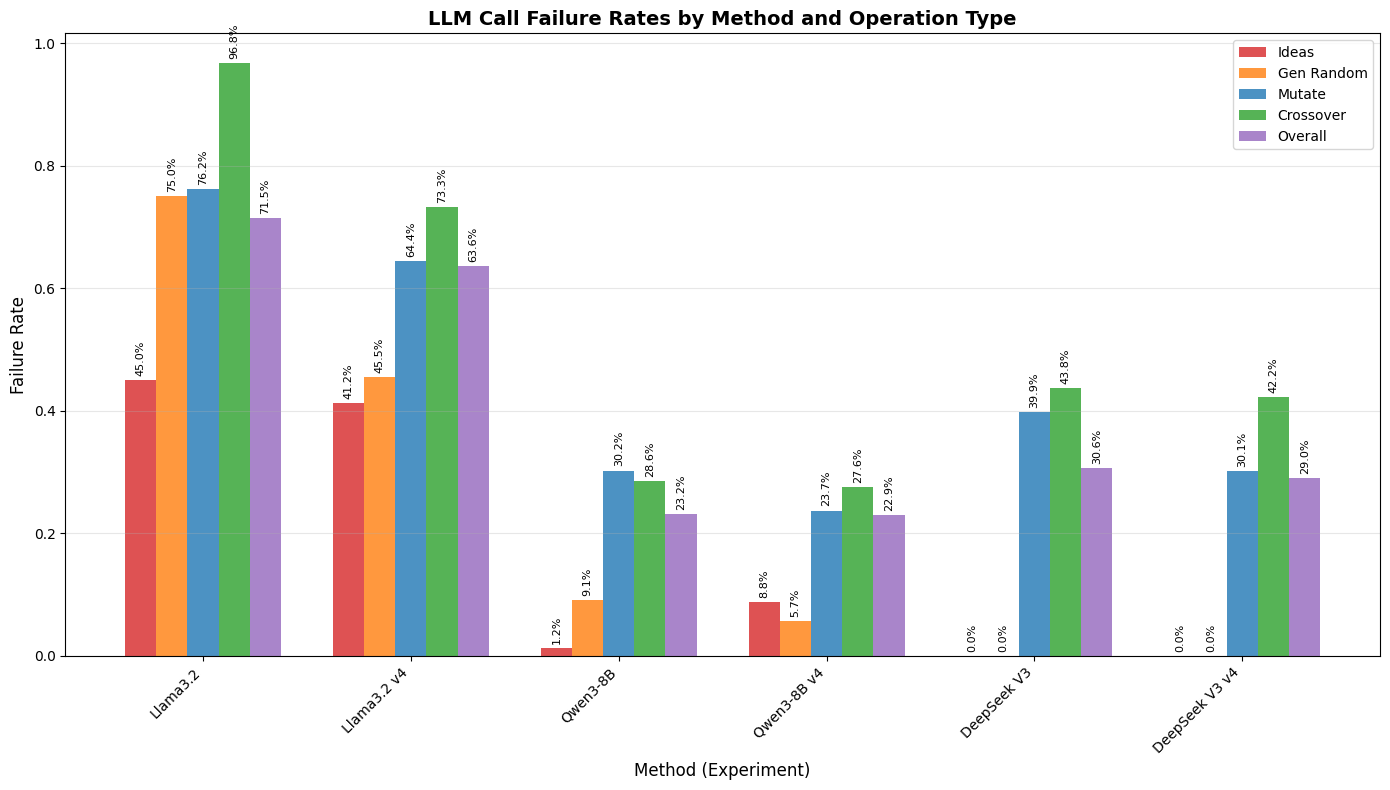

In [ ]:
# Create comprehensive method-wise failure rate summary table
print("\n=== METHOD-WISE FAILURE RATE SUMMARY TABLE ===")

# Create a comprehensive summary table with all operation types
method_failure_summary = pd.DataFrame({
    'Experiment': selected_experiments,
    'Method': [exp_labels.get(exp, f'Exp_{exp}') for exp in selected_experiments]
})

# Add failure rates for each operation type
# Ideas
ideas_rates = []
for exp in selected_experiments:
    row = method_summary_ideas[method_summary_ideas['experiment'] == exp]
    if len(row) > 0:
        ideas_rates.append(row.iloc[0]['ideas_failure_rate'])
    else:
        ideas_rates.append(np.nan)
method_failure_summary['Ideas_FR'] = ideas_rates

# Gen Random
gen_random_rates = []
for exp in selected_experiments:
    row = method_summary_gen_random[method_summary_gen_random['experiment'] == exp]
    if len(row) > 0:
        gen_random_rates.append(row.iloc[0]['gen_random_failure_rate'])
    else:
        gen_random_rates.append(np.nan)
method_failure_summary['GenRandom_FR'] = gen_random_rates

# Mutate
mutate_rates = []
for exp in selected_experiments:
    row = method_summary_mutate[method_summary_mutate['experiment'] == exp]
    if len(row) > 0:
        mutate_rates.append(row.iloc[0]['mutate_failure_rate'])
    else:
        mutate_rates.append(np.nan)
method_failure_summary['Mutate_FR'] = mutate_rates

# Crossover
crossover_rates = []
for exp in selected_experiments:
    row = method_summary_crossover[method_summary_crossover['experiment'] == exp]
    if len(row) > 0:
        crossover_rates.append(row.iloc[0]['crossover_failure_rate'])
    else:
        crossover_rates.append(np.nan)
method_failure_summary['Crossover_FR'] = crossover_rates

# Overall
overall_rates = []
for exp in selected_experiments:
    row = method_summary_overall[method_summary_overall['experiment'] == exp]
    if len(row) > 0:
        overall_rates.append(row.iloc[0]['overall_failure_rate'])
    else:
        overall_rates.append(np.nan)
method_failure_summary['Overall_FR'] = overall_rates

# Format the dataframe for display
method_failure_summary_formatted = method_failure_summary.copy()
for col in ['Ideas_FR', 'GenRandom_FR', 'Mutate_FR', 'Crossover_FR', 'Overall_FR']:
    method_failure_summary_formatted[col] = method_failure_summary_formatted[col].apply(lambda x: f"{x:.2%}" if pd.notna(x) else "N/A")

# Display the summary table
print("\nFailure Rates by Method (Experiment):")
print(method_failure_summary_formatted.to_string(index=False))

# Save the comprehensive summary table
save_csv_with_metadata(method_failure_summary, 
                      f'{output_dir}/{expr_name}_method_failure_rate_summary.csv',
                      "Comprehensive failure rate summary by method for all operation types")

# Save a formatted version for easy reading
with open(f'{output_dir}/{expr_name}_method_failure_rate_summary_formatted.txt', 'w') as f:
    f.write("METHOD-WISE FAILURE RATE SUMMARY\n")
    f.write(f"{'='*80}\n")
    f.write(f"Generated: {metadata['generated_at']}\n")
    f.write(f"Experiment Name: {expr_name}\n")
    f.write(f"{'='*80}\n\n")
    f.write("Failure Rates by Method (Experiment):\n")
    f.write(method_failure_summary_formatted.to_string(index=False))
    f.write("\n\n")
    f.write("Legend:\n")
    f.write("- FR = Failure Rate\n")
    f.write("- Ideas_FR: Failure rate for 'ideas' operations\n")
    f.write("- GenRandom_FR: Failure rate for 'gen_random' operations\n")
    f.write("- Mutate_FR: Failure rate for 'mutate' operations\n")
    f.write("- Crossover_FR: Failure rate for 'crossover' operations\n")
    f.write("- Overall_FR: Overall failure rate across all operations\n")

print(f"\n✓ Exported {expr_name}_method_failure_rate_summary.csv")
print(f"✓ Exported {expr_name}_method_failure_rate_summary_formatted.txt")

# Create a visualization for the method-wise failure rates
plt.figure(figsize=(14, 10))

# Prepare data for grouped bar chart
x = np.arange(len(selected_experiments))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 8))

# Create bars for each operation type
bars1 = ax.bar(x - 2*width, method_failure_summary['Ideas_FR'], width, label='Ideas', color='#d62728', alpha=0.8)
bars2 = ax.bar(x - width, method_failure_summary['GenRandom_FR'], width, label='Gen Random', color='#ff7f0e', alpha=0.8)
bars3 = ax.bar(x, method_failure_summary['Mutate_FR'], width, label='Mutate', color='#1f77b4', alpha=0.8)
bars4 = ax.bar(x + width, method_failure_summary['Crossover_FR'], width, label='Crossover', color='#2ca02c', alpha=0.8)
bars5 = ax.bar(x + 2*width, method_failure_summary['Overall_FR'], width, label='Overall', color='#9467bd', alpha=0.8)

# Add labels and formatting
ax.set_xlabel('Method (Experiment)', fontsize=12)
ax.set_ylabel('Failure Rate', fontsize=12)
ax.set_title('LLM Call Failure Rates by Method and Operation Type', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([exp_labels.get(exp, f'Exp_{exp}') for exp in selected_experiments], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.annotate(f'{height:.1%}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=8, rotation=90)

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)
autolabel(bars4)
autolabel(bars5)

plt.tight_layout()

# Save the plot
save_path = f'{output_dir}/{expr_name}_method_failure_rates_comparison.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved visualization to {save_path}")

plt.show()


=== GENERATING COMPREHENSIVE HEATMAP ===

✓ Saved comprehensive heatmap to /Users/xiaobocheng/final_project/image/syn2/failure_plot/prompt_v4/prompt_v4_comprehensive_failure_heatmap.png


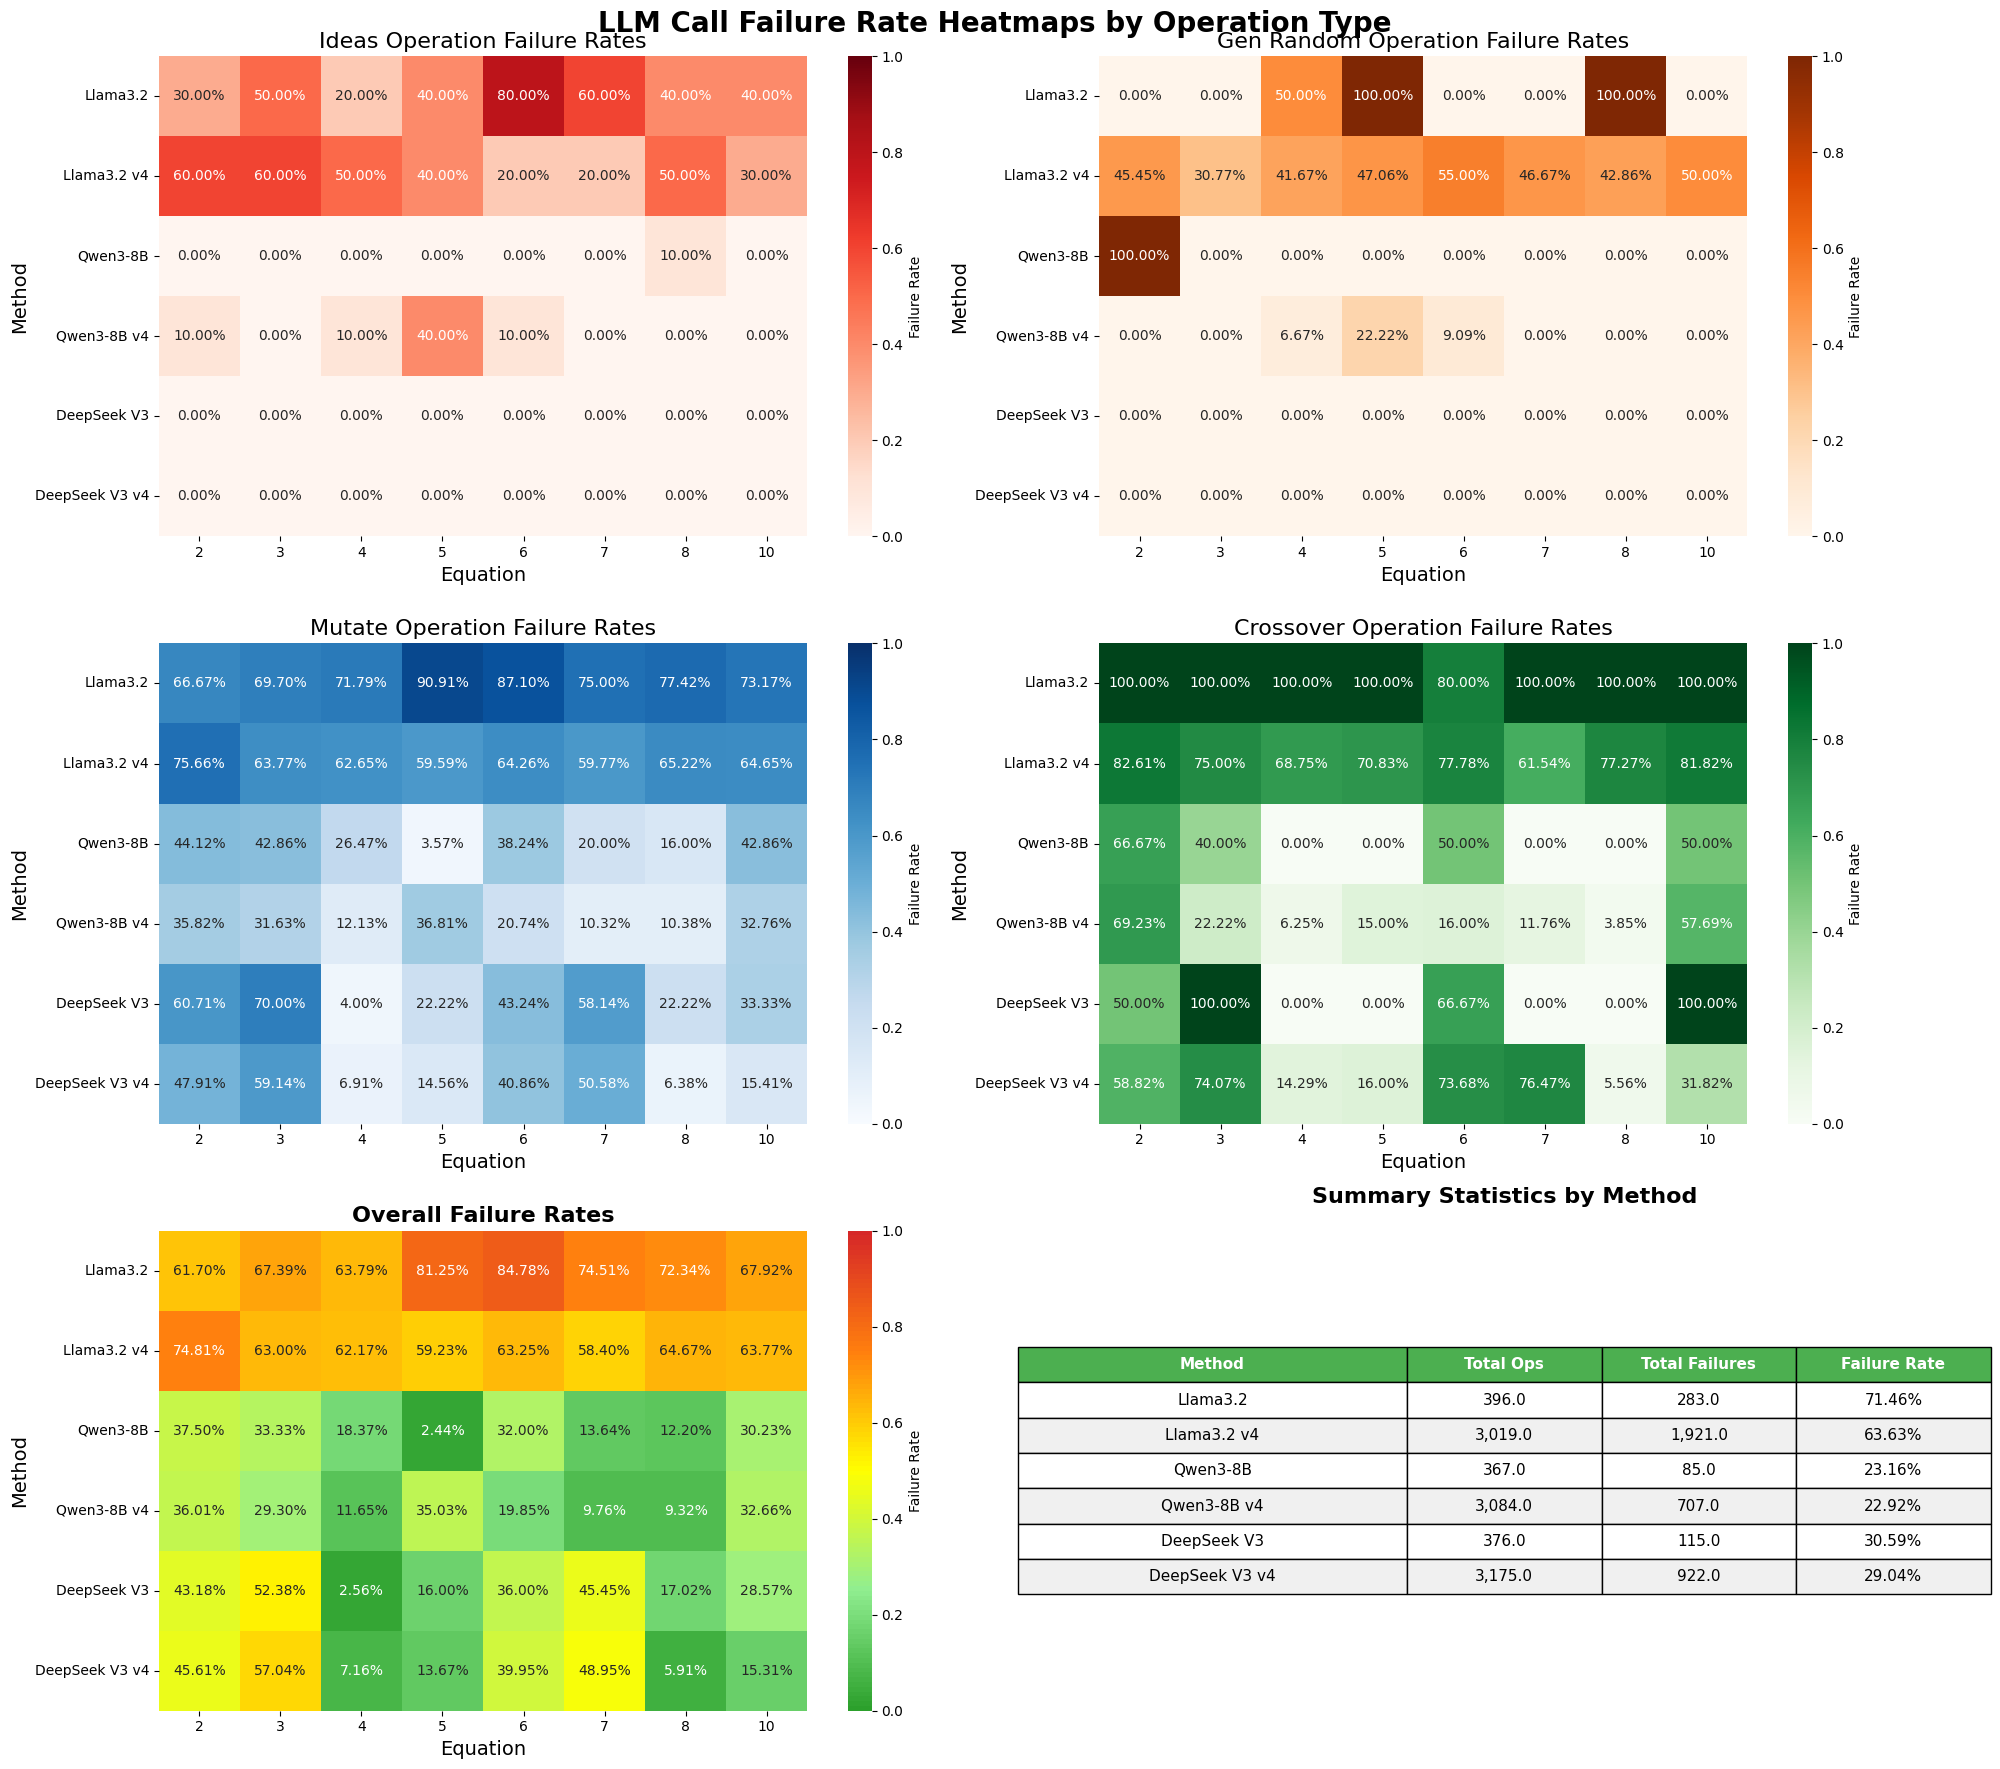

✓ Saved large overall heatmap to /Users/xiaobocheng/final_project/image/syn2/failure_plot/prompt_v4/prompt_v4_overall_failure_heatmap_large.png


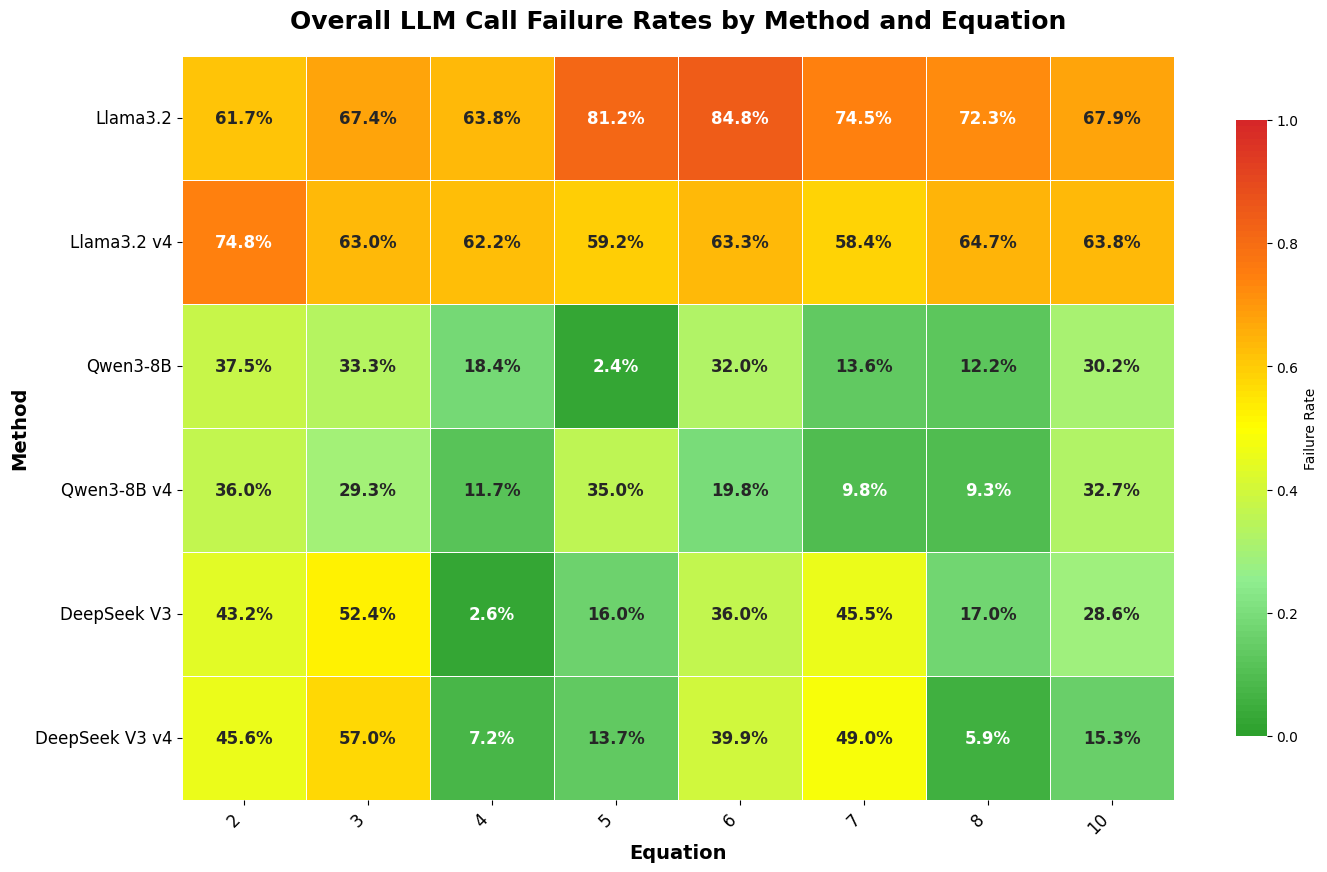


=== HEATMAP GENERATION COMPLETE ===
Generated comprehensive failure rate heatmaps with experiment names


In [ ]:
# Generate comprehensive heatmap with experiment names
print("\n=== GENERATING COMPREHENSIVE HEATMAP ===")

# Create a figure with subplots for different operation types
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('LLM Call Failure Rate Heatmaps by Operation Type', fontsize=20, fontweight='bold')

# Prepare experiment labels for y-axis
experiment_labels_for_plot = [exp_labels.get(exp, f'Exp_{exp}') for exp in selected_experiments]

# 1. Ideas Failure Rate Heatmap
sns.heatmap(ideas_failure_rate_table, annot=True, fmt='.2%', cmap='Reds', 
            cbar_kws={'label': 'Failure Rate'}, ax=axes[0,0], vmin=0, vmax=1)
axes[0,0].set_title('Ideas Operation Failure Rates', fontsize=16)
axes[0,0].set_xlabel('Equation', fontsize=14)
axes[0,0].set_ylabel('Method', fontsize=14)
axes[0,0].set_yticklabels(experiment_labels_for_plot, rotation=0)

# 2. Gen Random Failure Rate Heatmap
sns.heatmap(gen_random_failure_rate_table, annot=True, fmt='.2%', cmap='Oranges', 
            cbar_kws={'label': 'Failure Rate'}, ax=axes[0,1], vmin=0, vmax=1)
axes[0,1].set_title('Gen Random Operation Failure Rates', fontsize=16)
axes[0,1].set_xlabel('Equation', fontsize=14)
axes[0,1].set_ylabel('Method', fontsize=14)
axes[0,1].set_yticklabels(experiment_labels_for_plot, rotation=0)

# 3. Mutate Failure Rate Heatmap
sns.heatmap(mutate_failure_rate_table, annot=True, fmt='.2%', cmap='Blues', 
            cbar_kws={'label': 'Failure Rate'}, ax=axes[1,0], vmin=0, vmax=1)
axes[1,0].set_title('Mutate Operation Failure Rates', fontsize=16)
axes[1,0].set_xlabel('Equation', fontsize=14)
axes[1,0].set_ylabel('Method', fontsize=14)
axes[1,0].set_yticklabels(experiment_labels_for_plot, rotation=0)

# 4. Crossover Failure Rate Heatmap
sns.heatmap(crossover_failure_rate_table, annot=True, fmt='.2%', cmap='Greens', 
            cbar_kws={'label': 'Failure Rate'}, ax=axes[1,1], vmin=0, vmax=1)
axes[1,1].set_title('Crossover Operation Failure Rates', fontsize=16)
axes[1,1].set_xlabel('Equation', fontsize=14)
axes[1,1].set_ylabel('Method', fontsize=14)
axes[1,1].set_yticklabels(experiment_labels_for_plot, rotation=0)

# 5. Overall Failure Rate Heatmap
# Use a diverging colormap for overall rates
import matplotlib.colors as mcolors
colors_overall = ['#2ca02c', '#90ee90', '#ffff00', '#ff7f0e', '#d62728']
n_bins = 100
cmap_overall = mcolors.LinearSegmentedColormap.from_list('custom', colors_overall, N=n_bins)

sns.heatmap(overall_failure_rate_table, annot=True, fmt='.2%', cmap=cmap_overall, 
            cbar_kws={'label': 'Failure Rate'}, ax=axes[2,0], vmin=0, vmax=1)
axes[2,0].set_title('Overall Failure Rates', fontsize=16, fontweight='bold')
axes[2,0].set_xlabel('Equation', fontsize=14)
axes[2,0].set_ylabel('Method', fontsize=14)
axes[2,0].set_yticklabels(experiment_labels_for_plot, rotation=0)

# 6. Create a summary statistics table in the last subplot
axes[2,1].axis('tight')
axes[2,1].axis('off')

# Create summary statistics
summary_stats = []
for exp in selected_experiments:
    exp_name = exp_labels.get(exp, f'Exp_{exp}')
    row_data = method_summary_overall[method_summary_overall['experiment'] == exp]
    if len(row_data) > 0:
        total_ops = row_data.iloc[0]['total_operations']
        total_fails = row_data.iloc[0]['total_failures']
        overall_rate = row_data.iloc[0]['overall_failure_rate']
        summary_stats.append([exp_name, f"{total_ops:,}", f"{total_fails:,}", f"{overall_rate:.2%}"])

# Create table
table = axes[2,1].table(cellText=summary_stats,
                       colLabels=['Method', 'Total Ops', 'Total Failures', 'Failure Rate'],
                       cellLoc='center',
                       loc='center',
                       colWidths=[0.4, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Style the table
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_facecolor('#4CAF50')
        cell.set_text_props(weight='bold', color='white')
    else:
        cell.set_facecolor('#f0f0f0' if i % 2 == 0 else 'white')

axes[2,1].set_title('Summary Statistics by Method', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()

# Save the comprehensive heatmap
save_path = f'{output_dir}/{expr_name}_comprehensive_failure_heatmap.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved comprehensive heatmap to {save_path}")

plt.show()

# Also create a single large heatmap for overall failure rates with better visibility
plt.figure(figsize=(16, 10))

# Create the heatmap with custom styling
ax = sns.heatmap(overall_failure_rate_table, 
                 annot=True, 
                 fmt='.1%', 
                 cmap=cmap_overall,
                 cbar_kws={'label': 'Failure Rate', 'shrink': 0.8},
                 vmin=0, 
                 vmax=1,
                 linewidths=0.5,
                 square=True,
                 annot_kws={'fontsize': 12, 'fontweight': 'bold'})

# Customize labels
ax.set_yticklabels(experiment_labels_for_plot, rotation=0, fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)

# Add title and labels
plt.title('Overall LLM Call Failure Rates by Method and Equation', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Equation', fontsize=14, fontweight='bold')
plt.ylabel('Method', fontsize=14, fontweight='bold')

# Add grid for better readability
ax.set_facecolor('#f8f8f8')

# Save the single heatmap
save_path = f'{output_dir}/{expr_name}_overall_failure_heatmap_large.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved large overall heatmap to {save_path}")

plt.show()

print("\n=== HEATMAP GENERATION COMPLETE ===")
print(f"Generated comprehensive failure rate heatmaps with experiment names")

In [ ]:
# Create additional visualizations

# 1. Overall failure rate comparison across experiments
plt.figure(figsize=(14, 8))

# Apply plot_sequence if specified
method_summary_overall_ordered = method_summary_overall.copy()
if 'plot_sequence' in globals() and plot_sequence:
    # Reorder method_summary_overall to match plot_sequence
    method_summary_overall_ordered = method_summary_overall.set_index('experiment').reindex(selected_experiments).reset_index()

overall_failure_rates = method_summary_overall_ordered.sort_values('overall_failure_rate')
bars = plt.bar(range(len(overall_failure_rates)), overall_failure_rates['overall_failure_rate'], 
                color=['#2ca02c' if rate < 0.4 else '#ff7f0e' if rate < 0.6 else '#d62728' 
                       for rate in overall_failure_rates['overall_failure_rate']], 
                alpha=0.8, edgecolor='black')

# Add experiment labels
experiment_labels = [exp_labels.get(exp, f'Exp_{exp}') for exp in overall_failure_rates['experiment']]
plt.xticks(range(len(overall_failure_rates)), experiment_labels, rotation=45, ha='right')

plt.ylabel('Overall Failure Rate', fontsize=12)
plt.xlabel('Experiment', fontsize=12)
plt.title('Overall LLM Call Failure Rates by Experiment', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars, overall_failure_rates['overall_failure_rate'])):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{rate:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

# Save the plot in the experiment folder with expr_name prefix
save_path = f'{output_dir}/{expr_name}_overall_failure_rate_comparison.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

plt.show()

# 2. Operation type failure rate comparison
plt.figure(figsize=(14, 8))

operation_types = ['Ideas', 'Gen Random', 'Mutate', 'Crossover']
operation_rates = [
    total_ideas_failed/total_ideas if total_ideas > 0 else 0,
    total_gen_random_failed/total_gen_random if total_gen_random > 0 else 0,
    total_mutate_failed/total_mutate if total_mutate > 0 else 0,
    total_crossover_failed/total_crossover if total_crossover > 0 else 0
]

colors = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']
bars = plt.bar(operation_types, operation_rates, color=colors, alpha=0.8, edgecolor='black')

plt.ylabel('Failure Rate', fontsize=12)
plt.xlabel('Operation Type', fontsize=12)
plt.title('LLM Call Failure Rates by Operation Type', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, rate in zip(bars, operation_rates):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{rate:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

# Save the plot in the experiment folder with expr_name prefix
save_path = f'{output_dir}/{expr_name}_operation_type_failure_rates.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

plt.show()

# 3. Heatmap of overall failure rates
plt.figure(figsize=(16, 8))

# Reindex overall_heatmap to match the desired order
overall_heatmap = overall_failure_rate_table

# Create a custom colormap
import matplotlib.colors as mcolors
colors = ['#2ca02c', '#90ee90', '#ffff00', '#ff7f0e', '#d62728']
n_bins = 100
cmap = mcolors.LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

sns.heatmap(overall_heatmap, annot=True, fmt='.2f', cmap=cmap, 
            cbar_kws={'label': 'Failure Rate'}, vmin=0, vmax=1)

# Add experiment labels
exp_labels_list = [exp_labels.get(i, f'Exp_{i}') for i in overall_heatmap.index]
plt.yticks(range(len(exp_labels_list)), exp_labels_list, rotation=0)

plt.title('Overall LLM Call Failure Rates Heatmap (Experiments × Equations)', fontsize=14, fontweight='bold')
plt.xlabel('Equation', fontsize=12)
plt.ylabel('Experiment', fontsize=12)

plt.tight_layout()

# Save the plot in the experiment folder with expr_name prefix
save_path = f'{output_dir}/{expr_name}_overall_failure_heatmap.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

plt.show()

print(f"\n✅ All analysis complete! Files saved in: {output_dir}")
print(f"\n📊 VISUALIZATIONS GENERATED:")
print(f"  - {expr_name}_failure_heatmaps.png - 4-panel heatmaps by operation type")
print(f"  - {expr_name}_failure_by_method.png - Bar charts by method") 
print(f"  - {expr_name}_failure_by_equation.png - Bar charts by equation")
print(f"  - {expr_name}_overall_failure_rate_comparison.png - Overall comparison")
print(f"  - {expr_name}_operation_type_failure_rates.png - Rates by operation type")
print(f"  - {expr_name}_overall_failure_heatmap.png - Simple overall heatmap")
print(f"  - {expr_name}_comprehensive_failure_heatmap.png - 6-panel comprehensive view")
print(f"  - {expr_name}_overall_failure_heatmap_large.png - Large detailed heatmap")
print(f"  - {expr_name}_method_failure_rates_comparison.png - Grouped bar chart")

print(f"\n📄 DATA FILES GENERATED:")
print(f"  - {expr_name}_method_failure_rate_summary.csv - Comprehensive summary (ALL DATA)")
print(f"  - {expr_name}_method_failure_rate_summary_formatted.txt - Human-readable summary")
print(f"  - {expr_name}_detailed_data.csv - Raw detailed data")
print(f"  - {expr_name}_method_summaries.txt - Text summaries by method")
print(f"  - {expr_name}_equation_summaries.txt - Text summaries by equation")
print(f"  - {expr_name}_metadata.json - Generation metadata")

print(f"\nℹ️  Note: Individual operation CSV files have been disabled.")
print(f"    Use the comprehensive summary file for all failure rate data.")